# S3-DS-03/04 | Optimización de Hiperparámetros — Finalistas

**Sprint 3 — Científico de Datos**  
**Tareas:** S3-DS-03 (LightGBM HPO) y S3-DS-04 (XGBoost HPO)  
**Método:** Optuna TPE — 50 trials por modelo  

**Objetivo:** Maximizar ROC-AUC en el set de validación temporal  
**Split temporal:** train `< 2018-07-01` | validation `>= 2018-07-01`  

| Entregable | Archivo |
|---|---|
| Resultados tuning | `data/processed/10_tuning_results.json` |
| Modelo final | `models/final/modelo_final.pkl` |
| Reporte markdown | `reports/sprint_03/tuning_results.md` |
| Figuras | `reports/figures/sprint_03_*.png` |

In [11]:
from __future__ import annotations

import json
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f'Optuna {optuna.__version__}')
except ImportError:
    raise ImportError('Instala optuna: pip install optuna')

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Optuna 4.9.0
Imports OK


In [12]:
project_root = Path.cwd().resolve()
if not (project_root / 'data').exists():
    for candidate in [project_root, *project_root.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            project_root = candidate
            break

FEATURES_PATH  = project_root / 'data' / 'processed' / '06_features_selected.parquet'
SOURCE_PATH    = project_root / 'data' / 'processed' / '05_features_rfm.parquet'
BENCHMARK_PATH = project_root / 'data' / 'processed' / '09_model_benchmark.json'
TUNING_OUT     = project_root / 'data' / 'processed' / '10_tuning_results.json'
MODEL_OUT      = project_root / 'models' / 'final' / 'modelo_final.pkl'
FIGURES_DIR    = project_root / 'reports' / 'figures'

TARGET   = 'is_premium'
ID_COL   = 'customer_unique_id'
CUTOFF   = pd.Timestamp('2018-07-01')
SEED     = 42
N_TRIALS = 50

MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('project_root:', project_root)

project_root: C:\Users\marce\Documents\Code\Maestria\m13\miadas_mod_13_scrum


## 1. Carga de datos y split temporal

In [13]:
selected_df = pd.read_parquet(FEATURES_PATH)
temporal_df = pd.read_parquet(SOURCE_PATH, columns=[ID_COL, 'last_purchase'])

df = selected_df.merge(temporal_df, on=ID_COL, how='left', validate='one_to_one')

train_df = df[df['last_purchase'] < CUTOFF].copy()
val_df   = df[df['last_purchase'] >= CUTOFF].copy()

features     = [c for c in selected_df.columns if c not in {ID_COL, TARGET}]
cat_features = (train_df[features]
    .select_dtypes(include=['object', 'string', 'category'])
    .columns.tolist())
num_features = [c for c in features if c not in cat_features]

positives        = int(train_df[TARGET].sum())
negatives        = int(len(train_df) - positives)
scale_pos_weight = negatives / positives

print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')
print(f'Features: {len(features)} (num: {len(num_features)}, cat: {len(cat_features)})')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

Train: 83,589 | Val: 6,230
Features: 28 (num: 23, cat: 5)
scale_pos_weight: 3.6965


## 2. Preprocesamiento

In [14]:
def build_preprocessor() -> ColumnTransformer:
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features),
    ])


preprocessor = build_preprocessor()
X_train = preprocessor.fit_transform(train_df[features])
X_val   = preprocessor.transform(val_df[features])
y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values

cat_names     = (preprocessor
    .named_transformers_['cat']['encoder']
    .get_feature_names_out(cat_features)
    .tolist())
feature_names = num_features + cat_names

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'Features procesadas: {len(feature_names)}')

X_train shape: (83589, 160)
X_val shape:   (6230, 160)
Features procesadas: 160


## 3. Métricas de referencia (Baseline)

In [15]:
with open(BENCHMARK_PATH) as f:
    benchmark = json.load(f)

baseline_df = pd.DataFrame(benchmark['results'])
finalists   = benchmark['finalists']['selected']

b_lgbm = next(r for r in benchmark['results'] if r['model_name'] == 'lightgbm')
b_xgb  = next(r for r in benchmark['results'] if r['model_name'] == 'xgboost')

cols_show = ['model_name', 'roc_auc_val', 'gini_val', 'f1_val', 'recall_val', 'overfit_gap']
print('=== Métricas Baseline (sin tuning) ===')
display(
    baseline_df[baseline_df['model_name'].isin(finalists)][cols_show]
    .reset_index(drop=True)
    .round(4)
)

=== Métricas Baseline (sin tuning) ===


,model_name,roc_auc_val,gini_val,f1_val,recall_val,overfit_gap
0,lightgbm,0.8035,0.6070,0.5565,0.6653,0.037
1,xgboost,0.7982,0.5964,0.5504,0.6906,0.029


In [16]:
def evaluate(model, X, y, threshold=0.5):
    scores = model.predict_proba(X)[:, 1]
    preds  = (scores >= threshold).astype(int)
    roc    = float(roc_auc_score(y, scores))
    return {
        'roc_auc':   roc,
        'gini':      round(2 * roc - 1, 6),
        'pr_auc':    float(average_precision_score(y, scores)),
        'f1':        float(f1_score(y, preds, zero_division=0)),
        'precision': float(precision_score(y, preds, zero_division=0)),
        'recall':    float(recall_score(y, preds, zero_division=0)),
    }

## 4. Tuning — LightGBM (S3-DS-03)

**Espacio de búsqueda (TPE Bayesiana):**

| Parámetro | Rango | Escala |
|---|---|---|
| `num_leaves` | [20, 150] | lineal |
| `max_depth` | [3, 10] | lineal |
| `learning_rate` | [0.01, 0.20] | log |
| `n_estimators` | [100, 500] | lineal |
| `min_child_samples` | [10, 100] | lineal |
| `subsample` | [0.6, 1.0] | lineal |
| `colsample_bytree` | [0.6, 1.0] | lineal |
| `reg_alpha` (L1) | [1e-8, 10.0] | log |
| `reg_lambda` (L2) | [1e-8, 10.0] | log |

In [17]:
def lgbm_objective(trial):
    params = dict(
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        n_estimators      = trial.suggest_int('n_estimators', 100, 500),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 100),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        class_weight      = 'balanced',
        n_jobs            = -1,
        random_state      = SEED,
        verbosity         = -1,
    )
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, scores)

In [18]:
print(f'Iniciando búsqueda LightGBM ({N_TRIALS} trials)...')
study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name='lgbm_hpo',
)
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_lgbm_params = study_lgbm.best_params
best_lgbm_roc    = study_lgbm.best_value
print()
print(f'Mejor ROC-AUC (val): {best_lgbm_roc:.6f}')
print('Mejores parámetros:')
for k, v in best_lgbm_params.items():
    print(f'  {k}: {v}')

Iniciando búsqueda LightGBM (50 trials)...


Best trial: 45. Best value: 0.808117: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


Mejor ROC-AUC (val): 0.808117
Mejores parámetros:
  num_leaves: 59
  max_depth: 8
  learning_rate: 0.054038945566405934
  n_estimators: 255
  min_child_samples: 68
  subsample: 0.9059228577785707
  colsample_bytree: 0.855428530082444
  reg_alpha: 6.735979730583029e-08
  reg_lambda: 0.0005641632739363156


In [19]:
best_lgbm_model = LGBMClassifier(
    **best_lgbm_params,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
    verbosity=-1,
)
best_lgbm_model.fit(X_train, y_train)

lgbm_train_m = evaluate(best_lgbm_model, X_train, y_train)
lgbm_val_m   = evaluate(best_lgbm_model, X_val,   y_val)
lgbm_gap     = round(lgbm_train_m['roc_auc'] - lgbm_val_m['roc_auc'], 4)

summary_lgbm = pd.DataFrame({
    'split':     ['train', 'validation'],
    'roc_auc':   [lgbm_train_m['roc_auc'],   lgbm_val_m['roc_auc']],
    'gini':      [lgbm_train_m['gini'],       lgbm_val_m['gini']],
    'f1':        [lgbm_train_m['f1'],         lgbm_val_m['f1']],
    'recall':    [lgbm_train_m['recall'],     lgbm_val_m['recall']],
    'precision': [lgbm_train_m['precision'],  lgbm_val_m['precision']],
})
print('=== LightGBM Tuneado ===')
display(summary_lgbm.round(4))
print(f'Gap overfit: {lgbm_gap:+.4f}')

=== LightGBM Tuneado ===


,split,roc_auc,gini,f1,recall,precision
0,train,0.8466,0.6932,0.5802,0.7451,0.4751
1,validation,0.8081,0.6162,0.5576,0.6617,0.4818


Gap overfit: +0.0385


## 5. Tuning — XGBoost (S3-DS-04)

**Espacio de búsqueda:**

| Parámetro | Rango | Escala |
|---|---|---|
| `n_estimators` | [100, 500] | lineal |
| `max_depth` | [3, 10] | lineal |
| `learning_rate` | [0.01, 0.20] | log |
| `min_child_weight` | [1, 10] | lineal |
| `subsample` | [0.6, 1.0] | lineal |
| `colsample_bytree` | [0.6, 1.0] | lineal |
| `gamma` | [0.0, 5.0] | lineal |
| `reg_alpha` (L1) | [1e-8, 10.0] | log |
| `reg_lambda` (L2) | [1e-8, 10.0] | log |

In [20]:
def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500),
        max_depth        = trial.suggest_int('max_depth', 3, 10),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        scale_pos_weight = scale_pos_weight,
        objective        = 'binary:logistic',
        eval_metric      = 'logloss',
        n_jobs           = -1,
        random_state     = SEED,
    )
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, scores)

In [21]:
print(f'Iniciando búsqueda XGBoost ({N_TRIALS} trials)...')
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    study_name='xgb_hpo',
)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_roc    = study_xgb.best_value
print()
print(f'Mejor ROC-AUC (val): {best_xgb_roc:.6f}')
print('Mejores parámetros:')
for k, v in best_xgb_params.items():
    print(f'  {k}: {v}')

Iniciando búsqueda XGBoost (50 trials)...


Best trial: 21. Best value: 0.807013: 100%|██████████| 50/50 [01:53<00:00,  2.26s/it]


Mejor ROC-AUC (val): 0.807013
Mejores parámetros:
  n_estimators: 331
  max_depth: 10
  learning_rate: 0.017563420206771783
  min_child_weight: 3
  subsample: 0.6001143839799814
  colsample_bytree: 0.7337219366496492
  gamma: 1.93801421494858
  reg_alpha: 9.752866483313244e-07
  reg_lambda: 0.40475076755318734


In [22]:
best_xgb_model = XGBClassifier(
    **best_xgb_params,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=SEED,
)
best_xgb_model.fit(X_train, y_train)

xgb_train_m = evaluate(best_xgb_model, X_train, y_train)
xgb_val_m   = evaluate(best_xgb_model, X_val,   y_val)
xgb_gap     = round(xgb_train_m['roc_auc'] - xgb_val_m['roc_auc'], 4)

summary_xgb = pd.DataFrame({
    'split':     ['train', 'validation'],
    'roc_auc':   [xgb_train_m['roc_auc'],   xgb_val_m['roc_auc']],
    'gini':      [xgb_train_m['gini'],       xgb_val_m['gini']],
    'f1':        [xgb_train_m['f1'],         xgb_val_m['f1']],
    'recall':    [xgb_train_m['recall'],     xgb_val_m['recall']],
    'precision': [xgb_train_m['precision'],  xgb_val_m['precision']],
})
print('=== XGBoost Tuneado ===')
display(summary_xgb.round(4))
print(f'Gap overfit: {xgb_gap:+.4f}')

=== XGBoost Tuneado ===


,split,roc_auc,gini,f1,recall,precision
0,train,0.8596,0.7191,0.6014,0.7526,0.5008
1,validation,0.8070,0.6140,0.5560,0.6371,0.4932


Gap overfit: +0.0525


## 6. Comparación: Baseline vs. Tuneado

In [23]:
comparison_data = [
    {
        'Modelo': 'LightGBM baseline',
        'ROC-AUC val': b_lgbm['roc_auc_val'],
        'Gini val':    b_lgbm['gini_val'],
        'F1 val':      b_lgbm['f1_val'],
        'Recall val':  b_lgbm['recall_val'],
        'Gap overfit': b_lgbm['overfit_gap'],
    },
    {
        'Modelo': 'LightGBM tuneado',
        'ROC-AUC val': lgbm_val_m['roc_auc'],
        'Gini val':    lgbm_val_m['gini'],
        'F1 val':      lgbm_val_m['f1'],
        'Recall val':  lgbm_val_m['recall'],
        'Gap overfit': lgbm_gap,
    },
    {
        'Modelo': 'XGBoost baseline',
        'ROC-AUC val': b_xgb['roc_auc_val'],
        'Gini val':    b_xgb['gini_val'],
        'F1 val':      b_xgb['f1_val'],
        'Recall val':  b_xgb['recall_val'],
        'Gap overfit': b_xgb['overfit_gap'],
    },
    {
        'Modelo': 'XGBoost tuneado',
        'ROC-AUC val': xgb_val_m['roc_auc'],
        'Gini val':    xgb_val_m['gini'],
        'F1 val':      xgb_val_m['f1'],
        'Recall val':  xgb_val_m['recall'],
        'Gap overfit': xgb_gap,
    },
]

comparison_df = pd.DataFrame(comparison_data)

print('=== Baseline vs. Tuneado ===')
display(comparison_df.round(4))

=== Baseline vs. Tuneado ===


,Modelo,ROC-AUC val,Gini val,F1 val,Recall val,Gap overfit
0,LightGBM baseline,0.8035,0.6070,0.5565,0.6653,0.0370
1,LightGBM tuneado,0.8081,0.6162,0.5576,0.6617,0.0385
2,XGBoost baseline,0.7982,0.5964,0.5504,0.6906,0.0290
3,XGBoost tuneado,0.8070,0.6140,0.5560,0.6371,0.0525


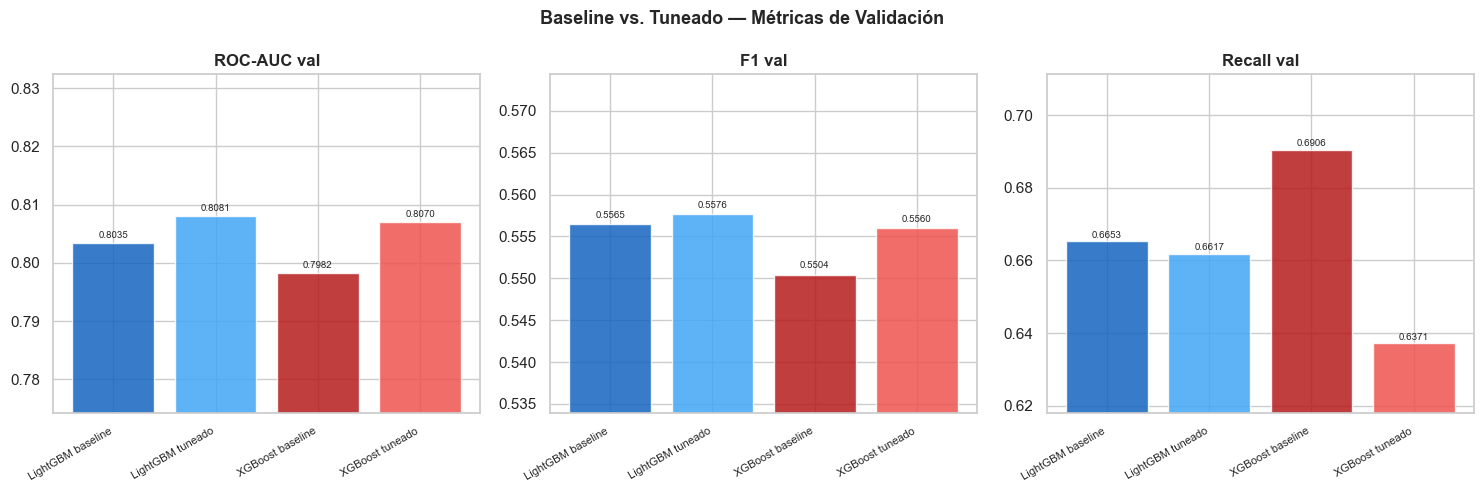

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_plot = ['ROC-AUC val', 'F1 val', 'Recall val']
colors = ['#1565C0', '#42A5F5', '#B71C1C', '#EF5350']
x = np.arange(len(comparison_df))

for ax, metric in zip(axes, metrics_plot):
    vals = comparison_df[metric].values
    bars = ax.bar(x, vals, color=colors, alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['Modelo'], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(min(vals) * 0.97, max(vals) * 1.03)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7,
        )

plt.suptitle('Baseline vs. Tuneado — Métricas de Validación', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_tuning_comparison.png', dpi=120)
plt.show()

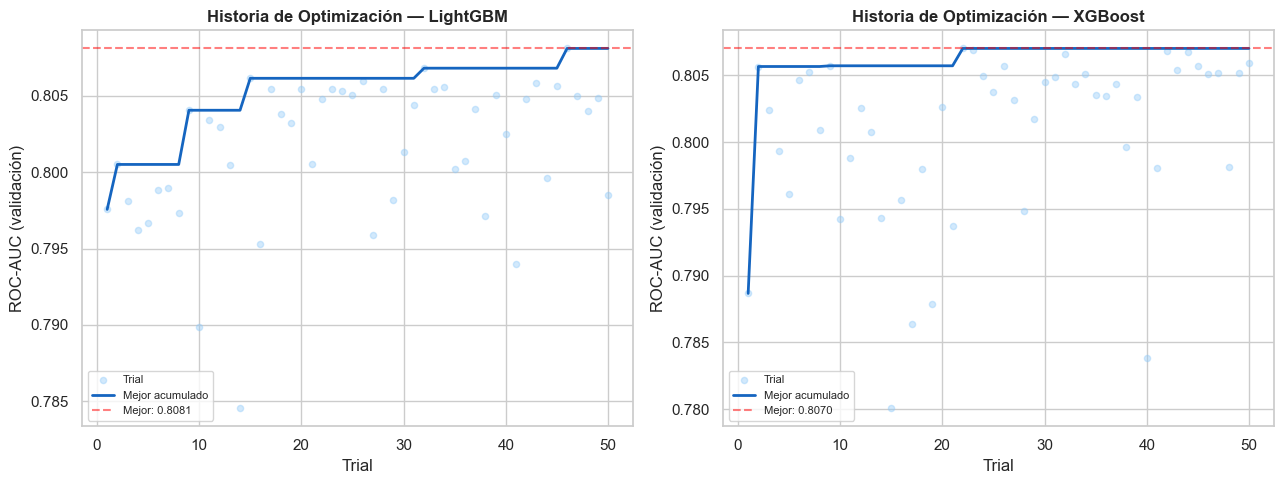

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, study, label in [
    (axes[0], study_lgbm, 'LightGBM'),
    (axes[1], study_xgb,  'XGBoost'),
]:
    vals     = [t.value for t in study.trials if t.value is not None]
    best_acc = [max(vals[:i + 1]) for i in range(len(vals))]
    ax.scatter(range(1, len(vals) + 1), vals, alpha=0.4, s=20,
               color='#90CAF9', label='Trial')
    ax.plot(range(1, len(best_acc) + 1), best_acc,
            color='#1565C0', linewidth=2, label='Mejor acumulado')
    ax.axhline(best_acc[-1], linestyle='--', color='red', alpha=0.5,
               label=f'Mejor: {best_acc[-1]:.4f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('ROC-AUC (validación)')
    ax.set_title(f'Historia de Optimización — {label}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_optimization_history.png', dpi=120)
plt.show()

## 7. Curvas de Rendimiento

Comparación ROC y Precision-Recall para baseline y modelos tuneados.

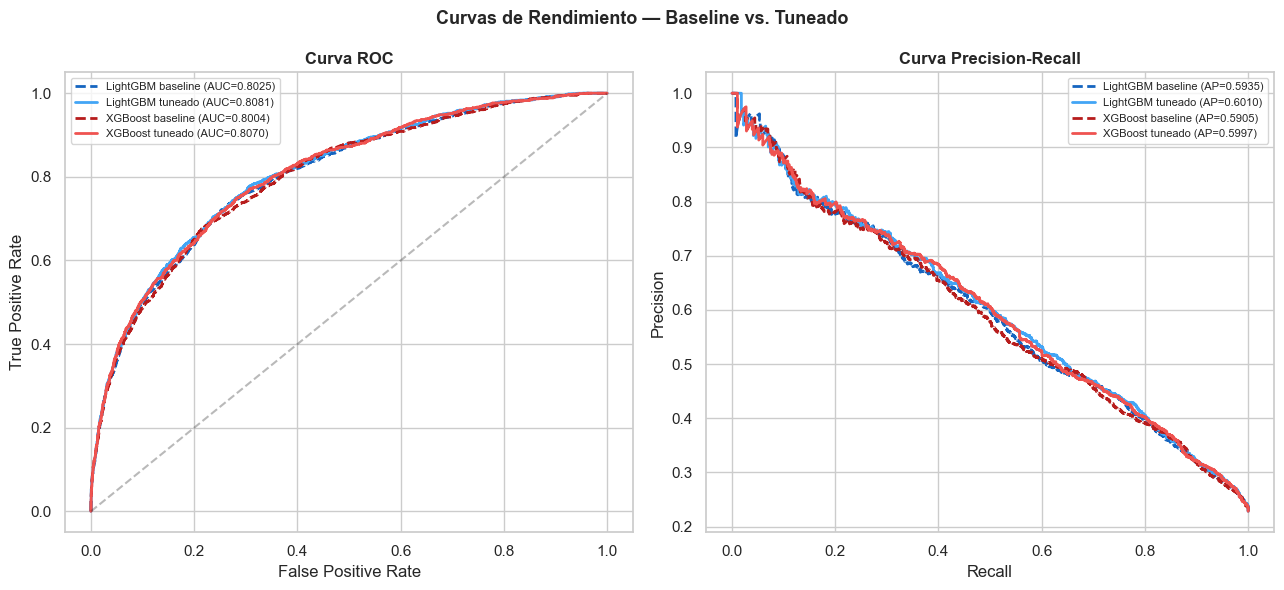

In [26]:
_lgbm_base = Pipeline([
    ('pre', build_preprocessor()),
    ('m', LGBMClassifier(
        n_estimators=250, learning_rate=0.05, num_leaves=31,
        subsample=0.9, colsample_bytree=0.8, class_weight='balanced',
        n_jobs=-1, random_state=SEED, verbosity=-1,
    )),
])
_lgbm_base.fit(train_df[features], train_df[TARGET])

_xgb_base = Pipeline([
    ('pre', build_preprocessor()),
    ('m', XGBClassifier(
        n_estimators=250, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.8, min_child_weight=2,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic', eval_metric='logloss',
        n_jobs=-1, random_state=SEED,
    )),
])
_xgb_base.fit(train_df[features], train_df[TARGET])

scores_dict = {
    'LightGBM baseline': _lgbm_base.predict_proba(val_df[features])[:, 1],
    'LightGBM tuneado':  best_lgbm_model.predict_proba(X_val)[:, 1],
    'XGBoost baseline':  _xgb_base.predict_proba(val_df[features])[:, 1],
    'XGBoost tuneado':   best_xgb_model.predict_proba(X_val)[:, 1],
}
curve_colors = {
    'LightGBM baseline': '#1565C0',
    'LightGBM tuneado':  '#42A5F5',
    'XGBoost baseline':  '#B71C1C',
    'XGBoost tuneado':   '#EF5350',
}
curve_styles = {
    'LightGBM baseline': '--',
    'LightGBM tuneado':  '-',
    'XGBoost baseline':  '--',
    'XGBoost tuneado':   '-',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for name, scores in scores_dict.items():
    color = curve_colors[name]
    ls    = curve_styles[name]

    fpr, tpr, _ = roc_curve(y_val, scores)
    auc = roc_auc_score(y_val, scores)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                 label=f'{name} (AUC={auc:.4f})')

    prec, rec, _ = precision_recall_curve(y_val, scores)
    ap = average_precision_score(y_val, scores)
    axes[1].plot(rec, prec, color=color, linestyle=ls, linewidth=2,
                 label=f'{name} (AP={ap:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Curvas de Rendimiento — Baseline vs. Tuneado', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_roc_pr_curves.png', dpi=120)
plt.show()

## 8. Feature Importance

Importancia basada en ganancia (gain) del árbol para los dos modelos tuneados.

Ganador:    LightGBM (tuneado)
Runner-up:  XGBoost (tuneado)


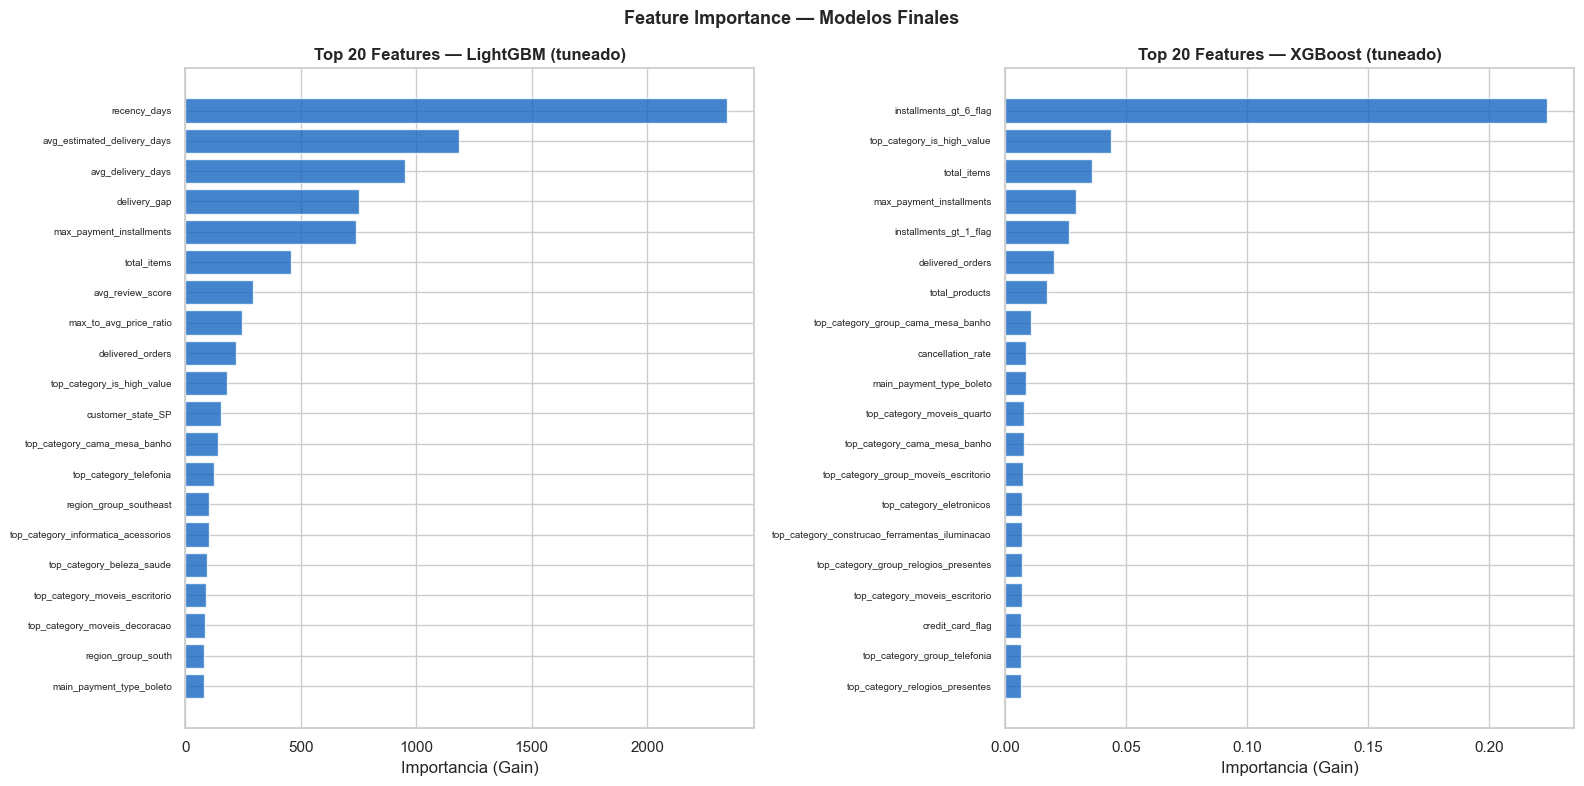


Top 10 features (LightGBM (tuneado)):
                    feature  importance
               recency_days        2346
avg_estimated_delivery_days        1185
          avg_delivery_days         952
               delivery_gap         751
   max_payment_installments         741
                total_items         460
           avg_review_score         295
     max_to_avg_price_ratio         244
           delivered_orders         220
 top_category_is_high_value         181


In [27]:
if lgbm_val_m['roc_auc'] >= xgb_val_m['roc_auc']:
    winner_model, winner_name, winner_type = best_lgbm_model, 'LightGBM (tuneado)', 'lgbm'
    runner_model, runner_name              = best_xgb_model,  'XGBoost (tuneado)'
else:
    winner_model, winner_name, winner_type = best_xgb_model,  'XGBoost (tuneado)',  'xgb'
    runner_model, runner_name              = best_lgbm_model, 'LightGBM (tuneado)'

print(f'Ganador:    {winner_name}')
print(f'Runner-up:  {runner_name}')

TOP_N = 20


def plot_fi(model, fnames, title, ax):
    fi_df = (
        pd.DataFrame({'feature': fnames, 'importance': model.feature_importances_})
        .sort_values('importance', ascending=False)
        .head(TOP_N)
    )
    ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
            color='#1565C0', alpha=0.8)
    ax.set_xlabel('Importancia (Gain)')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
    return fi_df


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fi_winner = plot_fi(winner_model, feature_names,
                    f'Top {TOP_N} Features — {winner_name}', axes[0])
fi_runner  = plot_fi(runner_model, feature_names,
                     f'Top {TOP_N} Features — {runner_name}', axes[1])

plt.suptitle('Feature Importance — Modelos Finales', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_feature_importance.png', dpi=120)
plt.show()

print()
print(f'Top 10 features ({winner_name}):')
print(fi_winner.head(10).to_string(index=False))

## 9. Análisis de Umbral

Precision, Recall y F1 en función del umbral de clasificación para el modelo ganador.

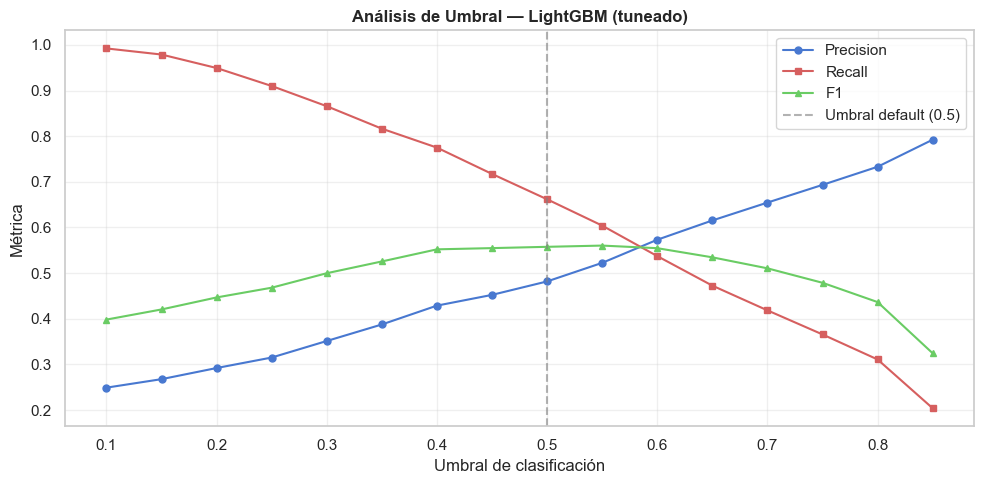

Umbral óptimo (mayor F1): 0.55
  Precision: 0.5225
  Recall:    0.6041
  F1:        0.5603


,threshold,precision,recall,f1
0,0.10,0.2491,0.9923,0.3982
1,0.15,0.2677,0.9789,0.4204
2,0.20,0.2921,0.9494,0.4467
3,0.25,0.3151,0.9100,0.4681
4,0.30,0.3513,0.8657,0.4998
5,0.35,0.3875,0.8165,0.5256
6,0.40,0.4288,0.7750,0.5521
7,0.45,0.4523,0.7173,0.5548
8,0.50,0.4818,0.6617,0.5576
9,0.55,0.5225,0.6041,0.5603


In [28]:
winner_scores = winner_model.predict_proba(X_val)[:, 1]
thresholds    = np.arange(0.10, 0.90, 0.05)

thresh_rows = []
for t in thresholds:
    preds = (winner_scores >= t).astype(int)
    thresh_rows.append({
        'threshold': round(float(t), 2),
        'precision': float(precision_score(y_val, preds, zero_division=0)),
        'recall':    float(recall_score(y_val, preds, zero_division=0)),
        'f1':        float(f1_score(y_val, preds, zero_division=0)),
    })

thresh_df = pd.DataFrame(thresh_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', ms=5, label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    'r-s', ms=5, label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        'g-^', ms=5, label='F1')
ax.axvline(x=0.5, linestyle='--', color='gray', alpha=0.6, label='Umbral default (0.5)')
ax.set_xlabel('Umbral de clasificación')
ax.set_ylabel('Métrica')
ax.set_title(f'Análisis de Umbral — {winner_name}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'sprint_03_threshold_analysis.png', dpi=120)
plt.show()

best_row = thresh_df.loc[thresh_df['f1'].idxmax()]
opt_t    = float(best_row['threshold'])
opt_p    = float(best_row['precision'])
opt_r    = float(best_row['recall'])
opt_f1   = float(best_row['f1'])

print(f'Umbral óptimo (mayor F1): {opt_t:.2f}')
print(f'  Precision: {opt_p:.4f}')
print(f'  Recall:    {opt_r:.4f}')
print(f'  F1:        {opt_f1:.4f}')
display(thresh_df.round(4))

## 10. Modelo Final — Exportación

Se construye el pipeline completo (preprocesador + modelo ganador con mejores hiperparámetros)
y se serializa en `.pkl`.

In [29]:
if winner_type == 'lgbm':
    final_estimator = LGBMClassifier(
        **best_lgbm_params,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1,
    )
else:
    final_estimator = XGBClassifier(
        **best_xgb_params,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=SEED,
    )

final_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', final_estimator),
])
final_pipeline.fit(train_df[features], train_df[TARGET])

pipeline_scores = final_pipeline.predict_proba(val_df[features])[:, 1]
pipeline_roc    = float(roc_auc_score(y_val, pipeline_scores))
print(f'ROC-AUC pipeline (val): {pipeline_roc:.6f}')

with open(MODEL_OUT, 'wb') as f:
    pickle.dump(final_pipeline, f)
print(f'Modelo exportado: {MODEL_OUT}')
print(f'Tamaño: {MODEL_OUT.stat().st_size / 1024:.1f} KB')

ROC-AUC pipeline (val): 0.808117
Modelo exportado: C:\Users\marce\Documents\Code\Maestria\m13\miadas_mod_13_scrum\models\final\modelo_final.pkl
Tamaño: 1256.7 KB


In [30]:
with open(MODEL_OUT, 'rb') as f:
    loaded_pipeline = pickle.load(f)

loaded_scores = loaded_pipeline.predict_proba(val_df[features])[:, 1]
loaded_roc    = float(roc_auc_score(y_val, loaded_scores))
delta         = abs(loaded_roc - pipeline_roc)

print(f'ROC-AUC (recargado desde .pkl): {loaded_roc:.6f}')
print(f'Diferencia vs pipeline original: {delta:.2e}')
print('Reproducibilidad OK' if delta < 1e-8 else 'ADVERTENCIA: diferencia detectada')

ROC-AUC (recargado desde .pkl): 0.808117
Diferencia vs pipeline original: 0.00e+00
Reproducibilidad OK


## 11. Persistencia de resultados

In [31]:
winner_val_m  = lgbm_val_m  if winner_type == 'lgbm' else xgb_val_m
winner_gap    = lgbm_gap    if winner_type == 'lgbm' else xgb_gap
winner_params = best_lgbm_params if winner_type == 'lgbm' else best_xgb_params

tuning_results = {
    'sprint': 3,
    'tasks': ['S3-DS-03', 'S3-DS-04'],
    'n_trials': N_TRIALS,
    'winner': {
        'model': winner_name,
        'type':  winner_type,
        'params': winner_params,
        'val_metrics': winner_val_m,
        'overfit_gap': winner_gap,
    },
    'runner_up': {
        'model': runner_name,
        'val_metrics': xgb_val_m if winner_type == 'lgbm' else lgbm_val_m,
    },
    'comparison': comparison_data,
    'best_threshold': {
        'value':     opt_t,
        'f1':        opt_f1,
        'precision': opt_p,
        'recall':    opt_r,
    },
    'model_path': str(MODEL_OUT),
}

with open(TUNING_OUT, 'w') as f:
    json.dump(tuning_results, f, indent=2, default=str)
print(f'Resultados guardados: {TUNING_OUT}')

Resultados guardados: C:\Users\marce\Documents\Code\Maestria\m13\miadas_mod_13_scrum\data\processed\10_tuning_results.json


In [32]:
def fmt(v):
    return f'{v:.4f}'


bl_roc = b_lgbm['roc_auc_val']
bl_gin = b_lgbm['gini_val']
bl_f1  = b_lgbm['f1_val']
bl_rec = b_lgbm['recall_val']
bl_gap = b_lgbm['overfit_gap']

bx_roc = b_xgb['roc_auc_val']
bx_gin = b_xgb['gini_val']
bx_f1  = b_xgb['f1_val']
bx_rec = b_xgb['recall_val']
bx_gap = b_xgb['overfit_gap']

l_roc = lgbm_val_m['roc_auc']
l_gin = lgbm_val_m['gini']
l_f1  = lgbm_val_m['f1']
l_rec = lgbm_val_m['recall']

x_roc = xgb_val_m['roc_auc']
x_gin = xgb_val_m['gini']
x_f1  = xgb_val_m['f1']
x_rec = xgb_val_m['recall']

lgbm_imp_roc = l_roc - bl_roc
lgbm_imp_f1  = l_f1  - bl_f1
xgb_imp_roc  = x_roc - bx_roc
xgb_imp_f1   = x_f1  - bx_f1

params_json = json.dumps(winner_params, indent=2)

report_lines = [
    '# Tuning de Hiperparámetros — Sprint 3',
    '',
    f'**Método:** Optuna TPE — {N_TRIALS} trials por modelo',
    '**Tareas:** S3-DS-03 (LightGBM) + S3-DS-04 (XGBoost)',
    '',
    '---',
    '',
    '## 1. Resultados de Optimización',
    '',
    '| Modelo | ROC-AUC val | Gini val | F1 val | Recall val | Gap overfit |',
    '|---|---|---|---|---|---|',
    f'| LightGBM baseline | {fmt(bl_roc)} | {fmt(bl_gin)} | {fmt(bl_f1)} | {fmt(bl_rec)} | {fmt(bl_gap)} |',
    f'| **LightGBM tuneado** | **{fmt(l_roc)}** | **{fmt(l_gin)}** | **{fmt(l_f1)}** | **{fmt(l_rec)}** | {fmt(lgbm_gap)} |',
    f'| XGBoost baseline | {fmt(bx_roc)} | {fmt(bx_gin)} | {fmt(bx_f1)} | {fmt(bx_rec)} | {fmt(bx_gap)} |',
    f'| **XGBoost tuneado** | **{fmt(x_roc)}** | **{fmt(x_gin)}** | **{fmt(x_f1)}** | **{fmt(x_rec)}** | {fmt(xgb_gap)} |',
    '',
    '## 2. Mejoras Obtenidas',
    '',
    f'- LightGBM: ROC-AUC {lgbm_imp_roc:+.4f} | F1 {lgbm_imp_f1:+.4f}',
    f'- XGBoost:  ROC-AUC {xgb_imp_roc:+.4f}  | F1 {xgb_imp_f1:+.4f}',
    '',
    f'## 3. Modelo Final: {winner_name}',
    '',
    f'**Archivo:** `{MODEL_OUT}`  ',
    f'**ROC-AUC val:** {fmt(winner_val_m["roc_auc"])}  ',
    f'**Gap overfit:** {fmt(winner_gap)}',
    '',
    '### Hiperparámetros óptimos',
    '',
    '```json',
    params_json,
    '```',
    '',
    '## 4. Umbral Óptimo',
    '',
    f'Umbral con mayor F1 = **{opt_t:.2f}**',
    f'- Precision: {opt_p:.4f}',
    f'- Recall:    {opt_r:.4f}',
    f'- F1:        {opt_f1:.4f}',
    '',
    '## 5. Figuras generadas',
    '',
    '- `sprint_03_tuning_comparison.png` — Baseline vs. tuneado por métrica',
    '- `sprint_03_optimization_history.png` — Historia de trials Optuna',
    '- `sprint_03_roc_pr_curves.png` — Curvas ROC y PR',
    '- `sprint_03_feature_importance.png` — Top 20 features por modelo',
    '- `sprint_03_threshold_analysis.png` — Análisis de umbral',
    '',
    '---',
    '',
    '*Generado desde `notebooks/sprint_03_modeling/02_hyperparameter_tuning.ipynb`*',
]

report_content = '\n'.join(report_lines)
report_path    = project_root / 'reports' / 'sprint_03' / 'tuning_results.md'
report_path.write_text(report_content, encoding='utf-8')
print(f'Reporte guardado: {report_path}')

Reporte guardado: C:\Users\marce\Documents\Code\Maestria\m13\miadas_mod_13_scrum\reports\sprint_03\tuning_results.md


## Resumen de entregables

In [33]:
print('=' * 65)
print('ENTREGABLES S3-DS-03 + S3-DS-04')
print('=' * 65)
print(f'  data/processed/10_tuning_results.json  OK')
print(f'  models/final/modelo_final.pkl          OK')
print(f'  reports/sprint_03/tuning_results.md    OK')
print()
print('FIGURAS:')
for p in sorted(FIGURES_DIR.glob('sprint_03_*.png')):
    print(f'  {p.name}')
print()
print(f'MODELO GANADOR: {winner_name}')
w_roc = lgbm_val_m['roc_auc'] if winner_type == 'lgbm' else xgb_val_m['roc_auc']
print(f'  ROC-AUC val:      {w_roc:.6f}')
print(f'  Gap overfit:      {winner_gap:+.4f}')
print(f'  Umbral óptimo F1: {opt_t:.2f}')

ENTREGABLES S3-DS-03 + S3-DS-04
  data/processed/10_tuning_results.json  OK
  models/final/modelo_final.pkl          OK
  reports/sprint_03/tuning_results.md    OK

FIGURAS:
  sprint_03_benchmark_roc_auc.png
  sprint_03_feature_importance.png
  sprint_03_optimization_history.png
  sprint_03_roc_pr_curves.png
  sprint_03_threshold_analysis.png
  sprint_03_tuning_comparison.png

MODELO GANADOR: LightGBM (tuneado)
  ROC-AUC val:      0.808117
  Gap overfit:      +0.0385
  Umbral óptimo F1: 0.55
